# Laboratorio 14 — Algoritmos Probabilísticos y Métodos de Monte Carlo

**Bootcamp IA Intermedio — Talento Tech Valle**  
**Módulo:** Diseño en lenguaje computacional  
**Duración estimada:** 2 horas

---

## Objetivos

1. Familiarizarse con los fundamentos de los algoritmos probabilísticos.
2. Generar números aleatorios y evaluar sus propiedades básicas.
3. Implementar el método de Monte Carlo para estimación y optimización.
4. Analizar la eficiencia y limitaciones de estos algoritmos.

---

## Estructura del laboratorio

| Ejercicio | Tema | Tiempo |
|-----------|------|--------|
| 1 | Generación de números aleatorios | 20 min |
| 2 | Monte Carlo para estimación de π | 30 min |
| 3 | Muestreo de importancia | 25 min |
| 4 | Optimización estocástica | 15 min |
| Reto final | Gestión de inventarios | - |

## Ejercicio 1 — Generación de Números Aleatorios

### ¿Por qué importa esto?

Todo método de Monte Carlo depende de números aleatorios de calidad.
En Python usamos **números pseudoaleatorios**: generados por un
algoritmo determinista que produce secuencias que *parecen* aleatorias.

### Propiedades deseables de un buen generador

- **Uniformidad:** todos los valores tienen la misma probabilidad
- **Independencia:** cada número no depende del anterior
- **Periodo largo:** tarda mucho en repetir la secuencia

### Lo que haremos

1. Generar 1000 números aleatorios entre 0 y 1
2. Imprimir los primeros 10 para inspección
3. Visualizar su distribución con un histograma

> Si la distribución es uniforme, todas las barras del histograma
> deberían tener alturas similares — ningún rango de valores
> debería aparecer más que otro.

### Paso 1 — Generar números aleatorios uniformes

Usamos `np.random.rand(n)` que genera `n` números aleatorios
entre 0 y 1 con distribución uniforme.

Luego visualizamos con un histograma para verificar
que la distribución es efectivamente uniforme.

Primeros 10 números generados:
[0.79679464 0.26119859 0.5640831  0.65380483 0.5829729  0.33315561
 0.32622215 0.39270877 0.24685259 0.09162518]


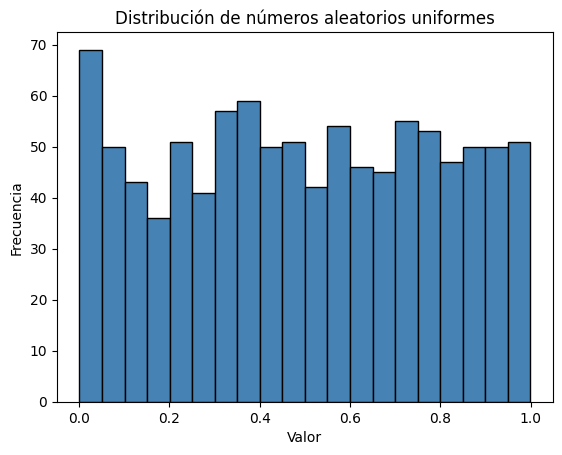

In [1]:
# Paso 1: Importar librerías y generar números aleatorios

import numpy as np
import matplotlib.pyplot as plt

# Generar 1000 números aleatorios entre 0 y 1
numeros_aleatorios = np.random.rand(1000)

print("Primeros 10 números generados:")
print(numeros_aleatorios[:10])

# Visualizar la distribución con un histograma
plt.hist(numeros_aleatorios, bins=20, color='steelblue', edgecolor='black')
plt.title("Distribución de números aleatorios uniformes")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.show()

## Ejercicio 2: Método de Monte Carlo para Estimación de Pi


 Este ejercicio guía a los estudiantes en la implementación de un método de Monte Carlo para aproximar el valor de π mediante simulación.

 Explicación del código:
  1. Se generan num_points puntos aleatorios en un cuadrado de lado 2.
  2. Se calcula la distancia de cada punto al origen. 
  3. Los puntos que están dentro del círculo unitario se cuentan. 
  4. Se aproxima π multiplicando la proporción de puntos dentro del círculo por 4.

Aproximación de Pi: 3.1192


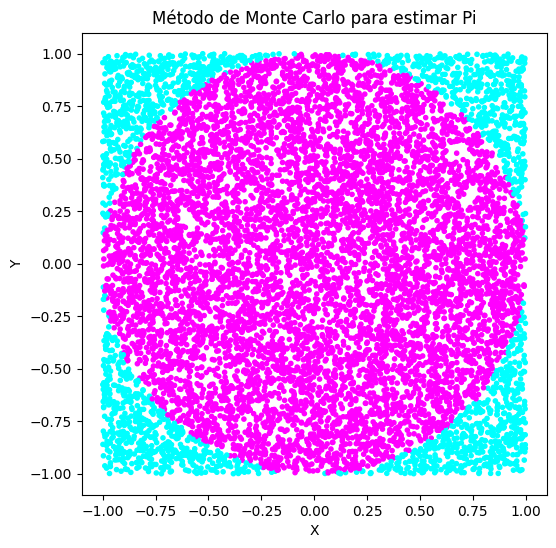

In [3]:
# Paso 1: Definir el número de puntos a generar
num_points = 10000

# Paso 2: Generar coordenadas (x, y) aleatorias entre -1 y 1
x_points = np.random.uniform(-1, 1, num_points)
y_points = np.random.uniform(-1, 1, num_points)

# Paso 3: Calcular la distancia de cada punto al origen (0,0)
distances = np.sqrt(x_points**2 + y_points**2)

# Paso 4: Contar los puntos que están dentro del círculo de radio 1
inside_circle = distances <= 1
num_inside_circle = np.sum(inside_circle)


# Paso 5: Aproximar el valor de pi usando la proporción de puntos dentro del círculo
pi_approx = (num_inside_circle / num_points) * 4
print("Aproximación de Pi:", pi_approx)

# Paso 6: Visualización
plt.figure(figsize=(6, 6))
plt.scatter(x_points, y_points, c=inside_circle, cmap='cool', marker='.')
plt.title("Método de Monte Carlo para estimar Pi")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


## Ejercicio 3: Muestreo de Importancia

Este ejercicio introduce el muestreo de importancia como una técnica para estimar la esperanza de una función cuando la distribución objetivo es difícil de muestrear directamente.

Explicación del código: 
1. Se define una función objetivo (distribución Gaussiana) y una función de muestreo (distribución de Cauchy). 
2. Se generan muestras de la distribución de Cauchy y se calcula el peso de cada muestra. 
3. Se calcula la esperanza ponderada como la media de los pesos.


In [4]:
# Paso 1: Definir la función objetivo y la función de peso
def target_function(x):
    return np.exp(-x**2) # Distribución Gaussiana como función objetivo

def importance_distribution(x):
    return 1 / (1 + x**2) # Distribución de Cauchy como función de muestreo

# Paso 2: Generar muestras de la distribución de muestreo
num_samples = 1000

samples = np.random.standard_cauchy(num_samples)

# Paso 3: Calcular los pesos y la estimación de la esperanza
weights = target_function(samples) / importance_distribution(samples) 
estimate = np.mean(weights)

print("Estimación de la esperanza con muestreo de importancia:", estimate)


Estimación de la esperanza con muestreo de importancia: 0.562298981445175


## Ejercicio 4: Optimización Estocástica para Maximización de Función

En este ejercicio, se utilizará el método de Monte Carlo para optimizar una función compleja. Se busca maximizar una función de dos variables.

 * Explicación del código:
 1. Se define una función objetivo compleja. 
 2. Se generan puntos aleatorios en el espacio de búsqueda. 
 3. La función se evalúa en cada punto, y se identifica el valor y punto máximo.

In [5]:
# Paso 1: Definir la función a optimizar
def objective_function(x, y):
    return np.sin(x) * np.cos(y) * np.exp(-(x**2 + y**2) / 10)

# Paso 2: Generar un conjunto de puntos aleatorios en el espacio de búsqueda
num_points = 10000
x_points = np.random.uniform(-5, 5, num_points)
y_points = np.random.uniform(-5, 5, num_points)

# Paso 3: Evaluar la función en cada punto y encontrar el valor máximo
values = objective_function(x_points, y_points)
max_value = np.max(values)
max_point = (x_points[np.argmax(values)], y_points[np.argmax(values)])

print("Valor máximo:", max_value) 
print("Punto de máxima función:", max_point)



Valor máximo: 0.8134646143216046
Punto de máxima función: (np.float64(1.3405807915152446), np.float64(0.0004664603002737522))
